In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

In [2]:
# NLP Libraries
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Custom modules
sys.path.append('../src')
from content_analysis.keyword_extraction import KeywordExtractor, PhraseExtractor
from visualization.plots import plot_keyword_frequency, create_wordcloud

# Settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)

In [4]:
# Download Required NLTK Data
import nltk

# Download necessary data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /Users/ellieryus/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ellieryus/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/ellieryus/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/ellieryus/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [5]:
# Load Processed Data
df = pd.read_csv('../data/processed/consumer_complaints_processed.csv')

print(f"Loaded: {df.shape[0]} complaints")
print(f"Columns: {df.columns.tolist()}")

# Get complaint text
complaints = df['complaint_clean'].astype(str)

Loaded: 1049446 complaints
Columns: ['Date received', 'year', 'month', 'month_name', 'day_of_week', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Company', 'State', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'complaint_clean', 'char_count', 'word_count', 'sentence_count', 'is_truncated']


In [6]:
# TF-IDF: UNIGRAMS (Single Words)

from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=100,        # Top 100 keywords
    min_df=10,               # Word must appear in at least 10 documents
    max_df=0.7,              # Ignore words in more than 70% of documents
    ngram_range=(1, 1),      # Unigrams only
    stop_words='english',    # Remove English stop words
    lowercase=True
)

# Fit and transform
print("Fitting TF-IDF on unigrams...")
tfidf_matrix = tfidf_vectorizer.fit_transform(complaints)

# Get feature names
feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"Extracted {len(feature_names)} unique words")
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

# Calculate mean TF-IDF score for each word
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()

# Create dataframe
keywords_df = pd.DataFrame({
    'keyword': feature_names,
    'tfidf_score': mean_tfidf
}).sort_values('tfidf_score', ascending=False)

# Display top 20
print("\nTOP 20 KEYWORDS (Unigrams):")
print(keywords_df.head(20).to_string(index=False))

Fitting TF-IDF on unigrams...
Extracted 100 unique words
TF-IDF matrix shape: (1049446, 100)

TOP 20 KEYWORDS (Unigrams):
    keyword  tfidf_score
     report     0.112248
    account     0.103369
information     0.096008
   accounts     0.092874
  reporting     0.087130
   consumer     0.066847
       debt     0.063728
         15     0.063113
 inaccurate     0.055504
         00     0.054754
    payment     0.050222
       fcra     0.049955
        act     0.045770
       late     0.045152
  inquiries     0.043684
   identity     0.042748
   reported     0.042170
    dispute     0.042148
    request     0.042134
       fair     0.041794


In [7]:
# TF-IDF: BIGRAMS (2-word phrases)

tfidf_bigram = TfidfVectorizer(
    max_features=100,
    min_df=5,
    max_df=0.7,
    ngram_range=(2, 2),      # Bigrams only
    stop_words='english',
    lowercase=True
)

print("\nFitting TF-IDF on bigrams...")
tfidf_bigram_matrix = tfidf_bigram.fit_transform(complaints)

# Get bigram features
bigram_features = tfidf_bigram.get_feature_names_out()
mean_tfidf_bigram = np.asarray(tfidf_bigram_matrix.mean(axis=0)).flatten()

# Create dataframe
bigrams_df = pd.DataFrame({
    'bigram': bigram_features,
    'tfidf_score': mean_tfidf_bigram
}).sort_values('tfidf_score', ascending=False)

print("\nTOP 20 BIGRAMS:")
print(bigrams_df.head(20).to_string(index=False))


Fitting TF-IDF on bigrams...

TOP 20 BIGRAMS:
                bigram  tfidf_score
         credit report     0.157725
      credit reporting     0.069022
           fair credit     0.053003
        identity theft     0.051987
         reporting act     0.049435
          late payment     0.041972
               15 code     0.038875
          alleged debt     0.036762
              act fcra     0.035746
                15 usc     0.034748
        credit bureaus     0.033602
        credit reports     0.033593
  personal information     0.033032
    information credit     0.031070
           credit file     0.030829
        account number     0.027688
       accounts credit     0.027154
inaccurate information     0.026978
           credit card     0.026696
      filing complaint     0.026219


In [8]:
# TF-IDF: TRIGRAMS (3-word phrases)

tfidf_trigram = TfidfVectorizer(
    max_features=50,
    min_df=3,
    max_df=0.7,
    ngram_range=(3, 3),      # Trigrams only
    stop_words='english',
    lowercase=True
)

print("\nFitting TF-IDF on trigrams...")
tfidf_trigram_matrix = tfidf_trigram.fit_transform(complaints)

# Get trigram features
trigram_features = tfidf_trigram.get_feature_names_out()
mean_tfidf_trigram = np.asarray(tfidf_trigram_matrix.mean(axis=0)).flatten()

# Create dataframe
trigrams_df = pd.DataFrame({
    'trigram': trigram_features,
    'tfidf_score': mean_tfidf_trigram
}).sort_values('tfidf_score', ascending=False)

print("\nTOP 20 TRIGRAMS:")
print(trigrams_df.head(20).to_string(index=False))


Fitting TF-IDF on trigrams...

TOP 20 TRIGRAMS:
                      trigram  tfidf_score
        fair credit reporting     0.095087
         credit reporting act     0.094565
           reporting act fcra     0.067527
    information credit report     0.044143
consumer financial protection     0.033458
    consumer reporting agency     0.032423
       accounts credit report     0.029649
    maximum possible accuracy     0.029479
        victim identity theft     0.028478
             reporting act 15     0.027507
    credit reporting agencies     0.025026
                  act 15 code     0.022936
     writing formally dispute     0.022693
     federal trade commission     0.022345
  financial protection bureau     0.021292
        result identity theft     0.020480
        removed credit report     0.018971
        violation fair credit     0.018895
    debt collection practices     0.018519
      credit reporting agency     0.018033


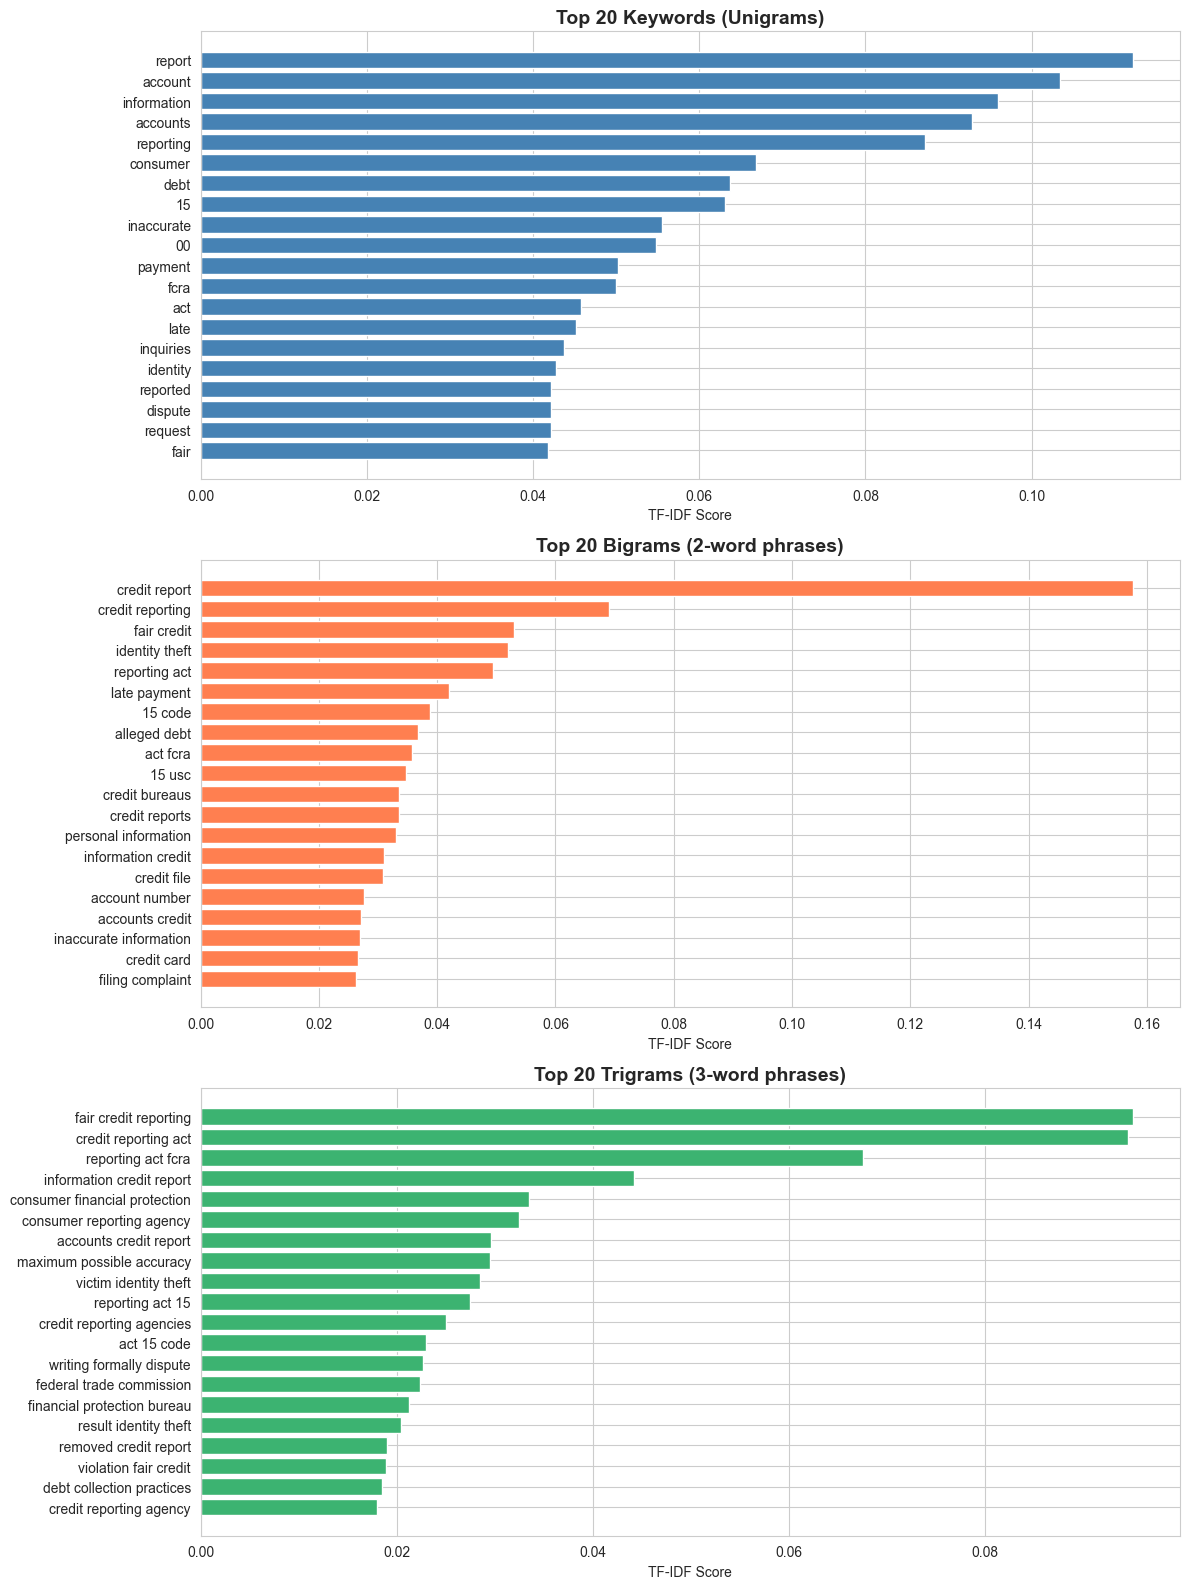

In [9]:
# VISUALIZATION 1: Top Keywords Bar Chart

fig, axes = plt.subplots(3, 1, figsize=(12, 16))

# Unigrams
top_unigrams = keywords_df.head(20)
axes[0].barh(range(len(top_unigrams)), top_unigrams['tfidf_score'], color='steelblue')
axes[0].set_yticks(range(len(top_unigrams)))
axes[0].set_yticklabels(top_unigrams['keyword'])
axes[0].set_xlabel('TF-IDF Score')
axes[0].set_title('Top 20 Keywords (Unigrams)', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()

# Bigrams
top_bigrams = bigrams_df.head(20)
axes[1].barh(range(len(top_bigrams)), top_bigrams['tfidf_score'], color='coral')
axes[1].set_yticks(range(len(top_bigrams)))
axes[1].set_yticklabels(top_bigrams['bigram'])
axes[1].set_xlabel('TF-IDF Score')
axes[1].set_title('Top 20 Bigrams (2-word phrases)', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()

# Trigrams
top_trigrams = trigrams_df.head(20)
axes[2].barh(range(len(top_trigrams)), top_trigrams['tfidf_score'], color='mediumseagreen')
axes[2].set_yticks(range(len(top_trigrams)))
axes[2].set_yticklabels(top_trigrams['trigram'])
axes[2].set_xlabel('TF-IDF Score')
axes[2].set_title('Top 20 Trigrams (3-word phrases)', fontsize=14, fontweight='bold')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/figures/top_ngrams_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

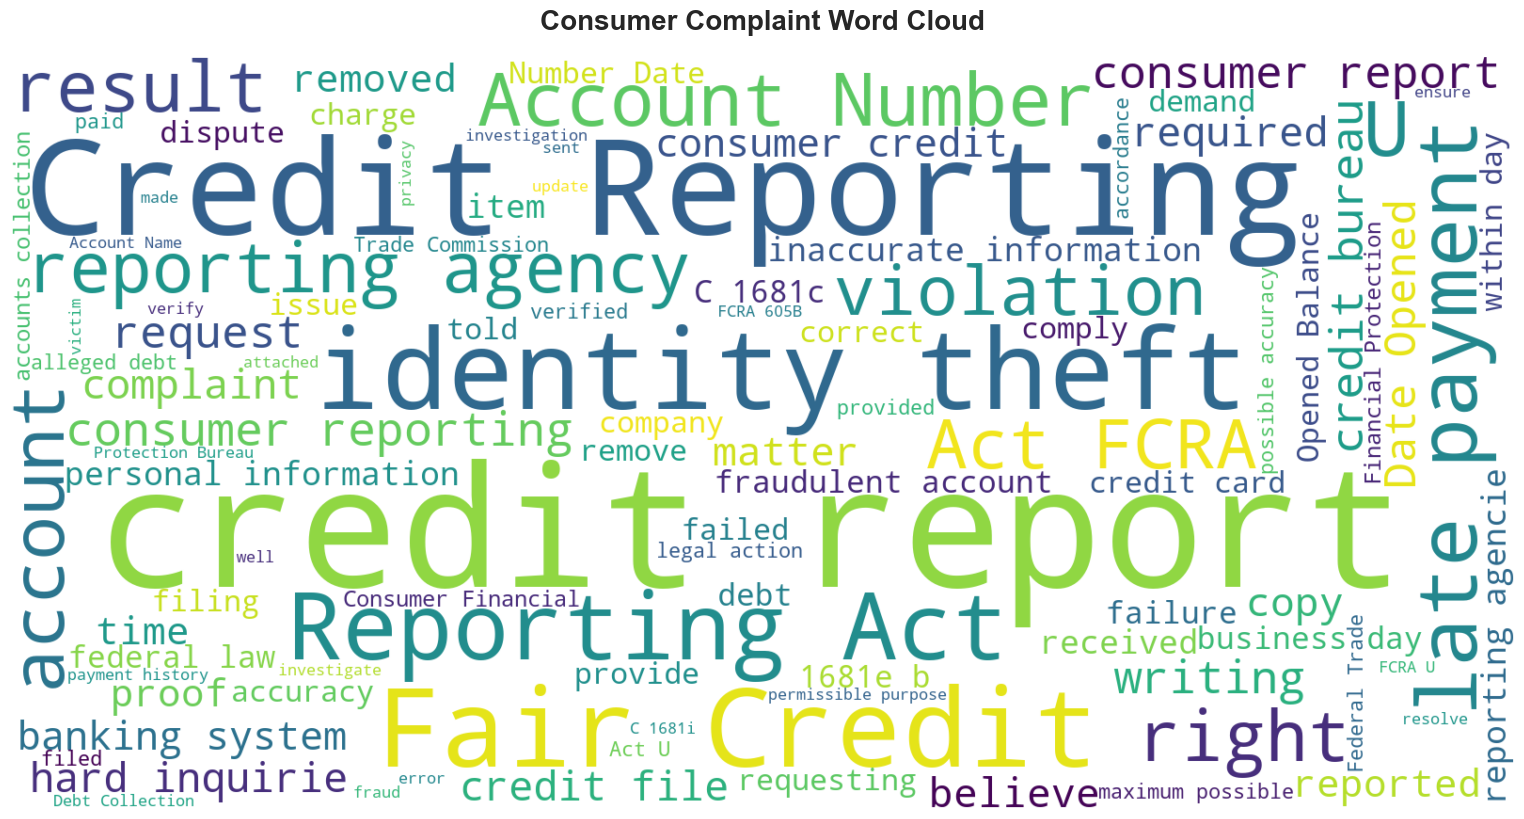

In [10]:
# VISUALIZATION 2: Word Cloud

from wordcloud import WordCloud

# Combine all text
all_text = ' '.join(complaints.astype(str))

# Remove stop words for better visualization
stop_words = set(stopwords.words('english'))

# Create word cloud
wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color='white',
    stopwords=stop_words,
    max_words=100,
    colormap='viridis',
    relative_scaling=0.5,
    min_font_size=10
).generate(all_text)

# Plot
plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Consumer Complaint Word Cloud', fontsize=20, fontweight='bold', pad=20)
plt.tight_layout(pad=0)
plt.savefig('../outputs/figures/wordcloud_overall.png', dpi=300, bbox_inches='tight')
plt.show()

Running MDS on 1000 complaints...


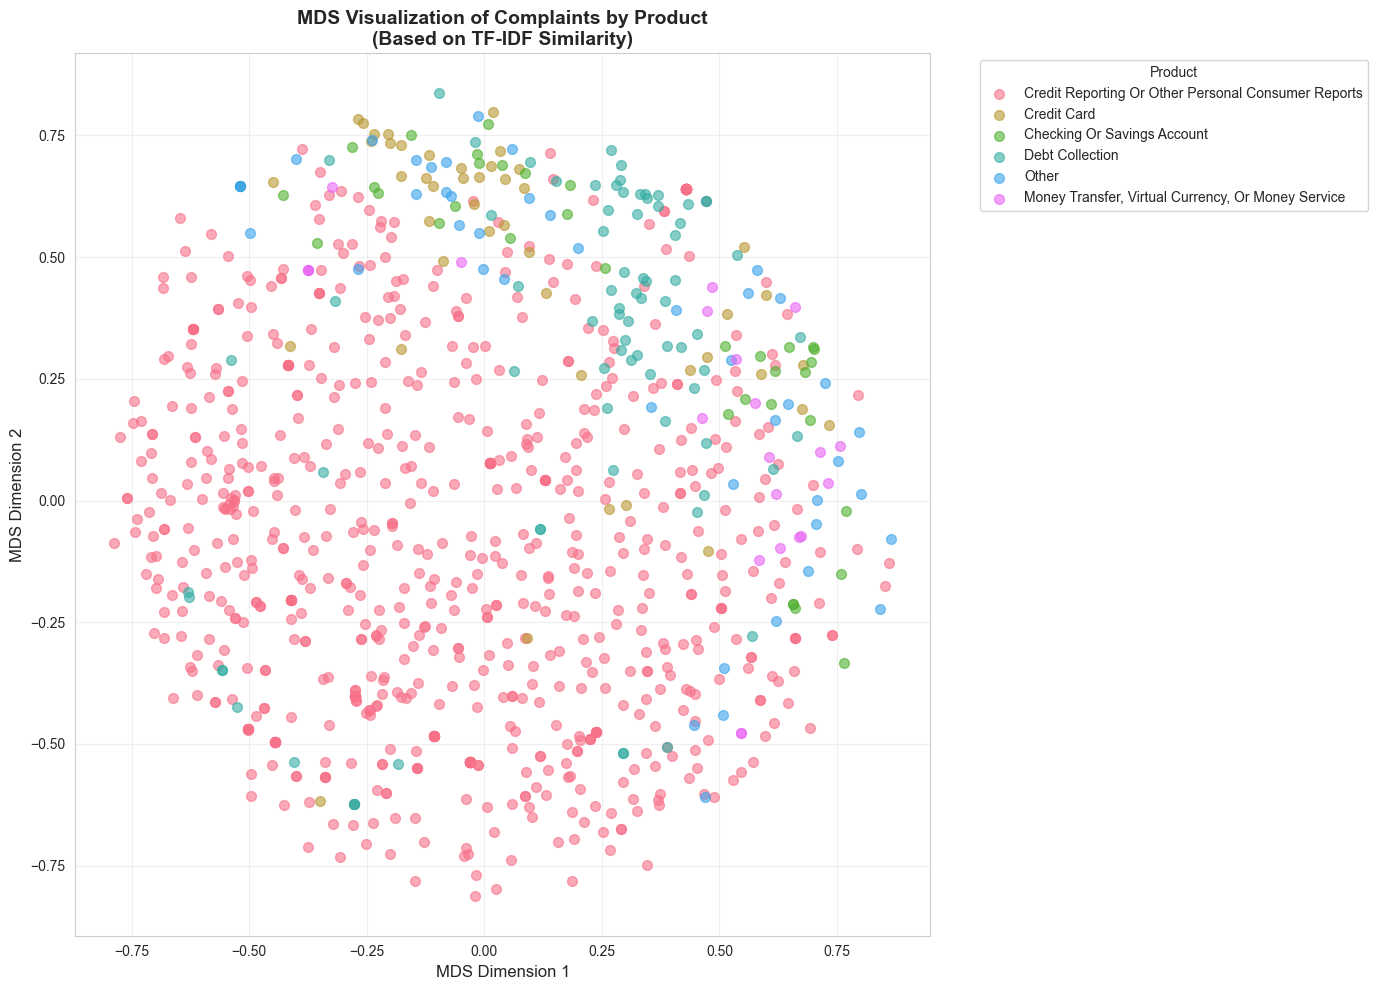

In [12]:
# MDS VISUALIZATION
from sklearn.manifold import MDS
from sklearn.metrics.pairwise import cosine_similarity

# Sample complaints for MDS (use subset for performance)
# For 1M complaints, use sample. For smaller datasets, use all.
sample_size = min(1000, len(df))  # Max 1000 for visualization clarity
df_sample = df.sample(sample_size, random_state=42)

# Get TF-IDF matrix for sample
sample_complaints = df_sample['complaint_clean'].astype(str)
tfidf_sample = tfidf_vectorizer.transform(sample_complaints)

# Calculate cosine similarity matrix
similarity_matrix = cosine_similarity(tfidf_sample)

# Convert similarity to distance (1 - similarity)
distance_matrix = 1 - similarity_matrix

# Apply MDS
print(f"Running MDS on {sample_size} complaints...")
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, n_init=1)
mds_coords = mds.fit_transform(distance_matrix)

# Add MDS coordinates to sample dataframe
df_sample['mds_x'] = mds_coords[:, 0]
df_sample['mds_y'] = mds_coords[:, 1]

# MDS PLOT - Color by Product

# Get top 5 products for coloring
top_products = df_sample['Product'].value_counts().head(5).index
df_sample['product_group'] = df_sample['Product'].apply(
    lambda x: x if x in top_products else 'Other'
)

# Create MDS scatter plot
plt.figure(figsize=(14, 10))

# Color palette
colors = sns.color_palette("husl", len(df_sample['product_group'].unique()))
product_groups = df_sample['product_group'].unique()

for i, product in enumerate(product_groups):
    mask = df_sample['product_group'] == product
    plt.scatter(
        df_sample[mask]['mds_x'],
        df_sample[mask]['mds_y'],
        label=product,
        alpha=0.6,
        s=50,
        color=colors[i]
    )

plt.xlabel('MDS Dimension 1', fontsize=12)
plt.ylabel('MDS Dimension 2', fontsize=12)
plt.title('MDS Visualization of Complaints by Product\n(Based on TF-IDF Similarity)', 
          fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Product')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/mds_by_product.png', dpi=300, bbox_inches='tight')
plt.show()


 TOP 30 MOST FREQUENT WORDS:
credit........................ 2514673
report........................ 1480723
account....................... 1451435
information................... 1344936
reporting..................... 1276076
consumer...................... 988966
accounts...................... 927913
fcra.......................... 724617
inaccurate.................... 584091
act........................... 550455
debt.......................... 496127
fair.......................... 487246
payment....................... 476289
identity...................... 458561
dispute....................... 439610
reported...................... 428271
date.......................... 426906
request....................... 426886
late.......................... 423698
theft......................... 410401
inquiries..................... 372122
fraudulent.................... 361671
balance....................... 359227
complaint..................... 354943
violation..................... 354497
please.........

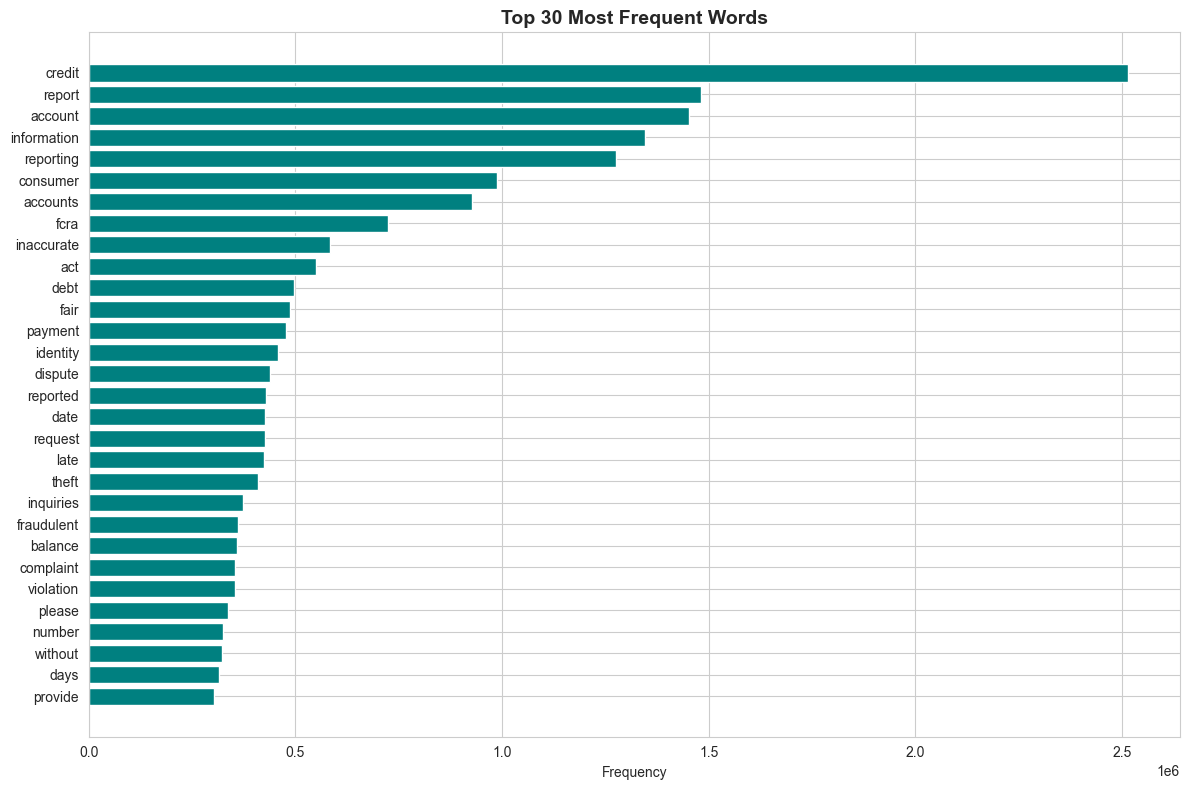

In [12]:
# Simple Word Frequency (not TF-IDF)

from collections import Counter
import re

def get_words(text):
    """Extract words from text"""
    # Convert to lowercase, remove punctuation
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    words = text.split()
    
    # Remove stop words
    words = [w for w in words if w not in stop_words and len(w) > 2]
    
    return words

# Extract all words
all_words = []
for complaint in complaints:
    all_words.extend(get_words(complaint))

# Count frequency
word_freq = Counter(all_words)
most_common = word_freq.most_common(30)

print("\n TOP 30 MOST FREQUENT WORDS:")
for word, count in most_common:
    print(f"{word:.<30} {count:>6}")

# Visualize
words, counts = zip(*most_common)

plt.figure(figsize=(12, 8))
plt.barh(range(len(words)), counts, color='teal')
plt.yticks(range(len(words)), words)
plt.xlabel('Frequency')
plt.title('Top 30 Most Frequent Words', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/figures/word_frequency.png', dpi=300, bbox_inches='tight')
plt.show()


TOP 30 COMMON BIGRAMS:
credit report........................... 876925
credit reporting........................ 575419
identity theft.......................... 383884
fair credit............................. 373182
reporting act........................... 347142
account number.......................... 214107
act fcra................................ 188053
reporting agency........................ 185522
consumer reporting...................... 173976
late payment............................ 165875
date opened............................. 149025
hard inquiries.......................... 135944
credit bureaus.......................... 131770
credit file............................. 128415
information credit...................... 127246
consumer report......................... 123922
consumer credit......................... 120034
banking system.......................... 118118
credit reports.......................... 116230
late payments........................... 112194
result identity.

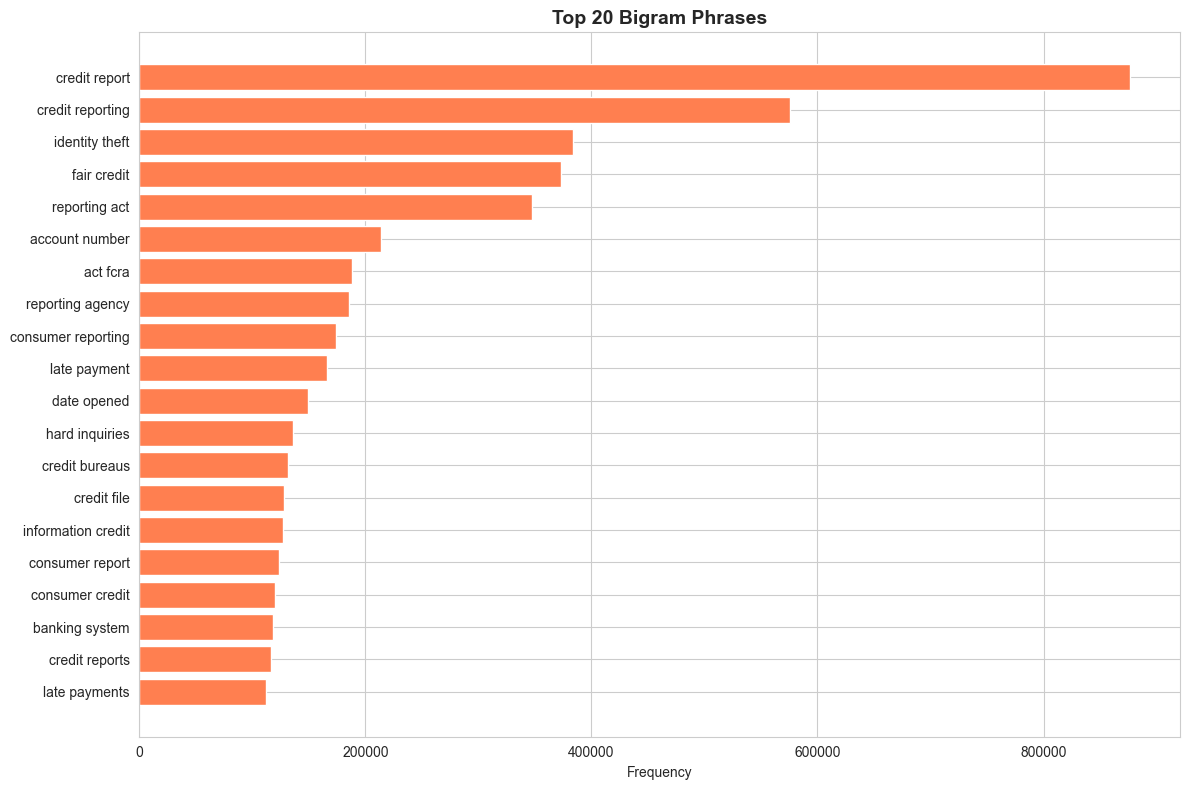

In [13]:
# Find Common Phrase Patterns

from nltk import bigrams, trigrams

# Extract bigrams
all_bigrams = []
for complaint in complaints:
    words = get_words(complaint)
    all_bigrams.extend(list(bigrams(words)))

# Count bigram frequency
bigram_freq = Counter(all_bigrams)
common_bigrams = bigram_freq.most_common(30)

print("\nTOP 30 COMMON BIGRAMS:")
for bigram, count in common_bigrams[:30]:
    print(f"{' '.join(bigram):.<40} {count:>6}")

# Visualize
bigram_labels = [' '.join(bg) for bg, _ in common_bigrams[:20]]
bigram_counts = [count for _, count in common_bigrams[:20]]

plt.figure(figsize=(12, 8))
plt.barh(range(len(bigram_labels)), bigram_counts, color='coral')
plt.yticks(range(len(bigram_labels)), bigram_labels)
plt.xlabel('Frequency')
plt.title('Top 20 Bigram Phrases', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/figures/bigram_frequency.png', dpi=300, bbox_inches='tight')
plt.show()